# 04 · Modelado y comparación de modelos

**Objetivo.** Entrenar y comparar rigurosamente varias familias de modelos bajo un protocolo idéntico, seleccionando el mejor por su **calidad probabilística**.

**Modelos**: Regresión Logística (baseline interpretable), Random Forest, Gradient Boosting, HistGradientBoosting (y XGBoost/LightGBM si están instalados).

**Protocolo**: cada modelo es un `Pipeline` (preprocesado + estimador); comparación por **validación cruzada estratificada** out-of-fold; evaluación final en un **test hold-out** reservado. Métricas: ROC-AUC, PR-AUC, LogLoss, Brier, ECE. Métrica de selección: **Brier** (regla de puntuación propia).

In [1]:
# Bootstrap: hace importable el paquete `xg` desde notebooks/ (src layout)
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == 'notebooks') else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from xg import config, features, models, analysis, visualization
from xg import data as data_loader
from xg.models import evaluation, statistics
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
config.ensure_dirs()
np.random.seed(config.RANDOM_STATE)
print('Proyecto:', config.PROJECT_ROOT.name)

Proyecto: TFM_xG_MachineLearning


In [2]:
raw, source = data_loader.build_shots_dataframe(source='auto')
feat = features.engineer_features(raw)
X, y, comp = features.split_features_target(feat, drop_penalties=True, return_competition=True)
if config.HOLDOUT_COMPETITION in set(comp.dropna()):
    (Xtr,ytr),(Xv,yv),(Xte,yte),(Xtrv,ytrv) = evaluation.make_competition_holdout_splits(
        X, y, comp, config.HOLDOUT_COMPETITION
    )
    print('test holdout:', config.HOLDOUT_COMPETITION)
else:
    (Xtr,ytr),(Xv,yv),(Xte,yte),(Xtrv,ytrv) = evaluation.make_splits(X, y)
    print('test aleatorio estratificado')
print('train',len(Xtr),'val',len(Xv),'test',len(Xte))

test holdout: UEFA Euro 2024
train 3441 val 861 test 1304


## 4.1 Comparación por validación cruzada
Probabilidades out-of-fold para una estimación honesta (sin optimismo).

In [3]:
names = models.available_model_names(); print('Modelos:', names)
pipes = {n: models.build_model_pipeline(n) for n in names}
cv = evaluation.evaluate_models_cv(pipes, Xtrv, ytrv)
# Guardado oficial: run_pipeline.py
cv.round(4)

Modelos: ['logistic_regression', 'logistic_splines', 'random_forest', 'gradient_boosting', 'hist_gradient_boosting']


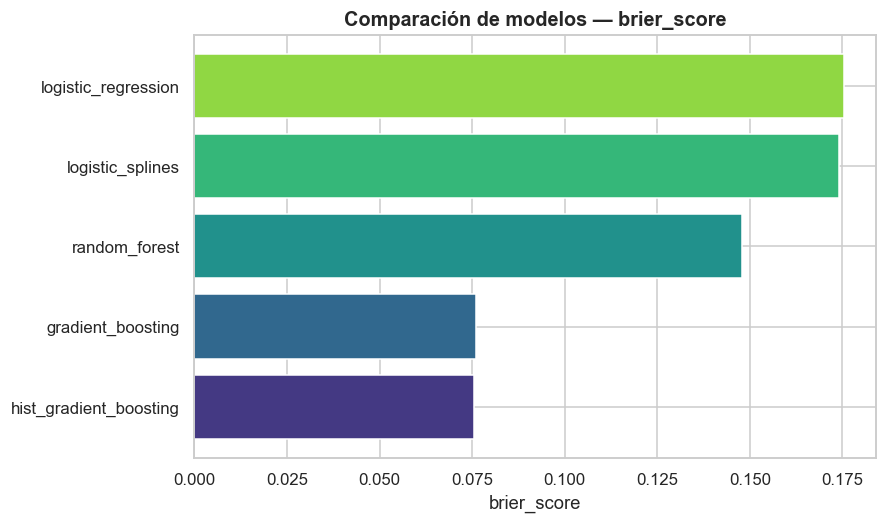

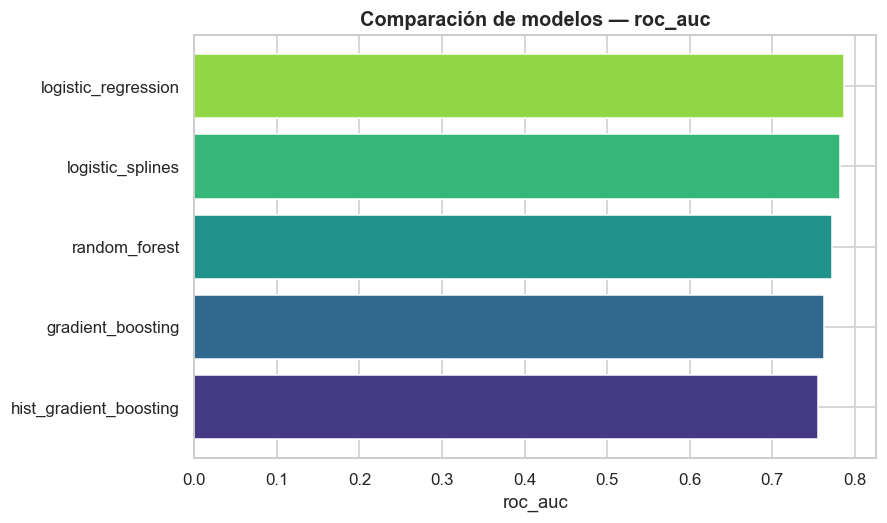

In [4]:
visualization.plot_metric_comparison(cv, 'brier_score', save_as='brier_comparison'); plt.show()
visualization.plot_metric_comparison(cv, 'roc_auc', save_as='roc_auc_comparison'); plt.show()

## 4.2 Entrenamiento del mejor modelo y baseline

In [5]:
best_name = cv.index[0]; print('Mejor modelo:', best_name)
best = models.build_model_pipeline(best_name).fit(Xtrv, ytrv)
baseline = models.build_model_pipeline('logistic_regression').fit(Xtrv, ytrv)
# Guardado oficial de modelos: run_pipeline.py

Mejor modelo: hist_gradient_boosting


## 4.3 Evaluación en test hold-out + curvas ROC/PR

In [6]:
res = {}
for label, m in [(best_name, best), ('logistic_regression', baseline)]:
    met, prob = evaluation.evaluate_on_test(m, Xte, yte, label)
    res[label] = (yte.values, prob)
rows = [evaluation.evaluate_on_test(best, Xte, yte, best_name)[0],
        evaluation.evaluate_on_test(baseline, Xte, yte, 'logistic_regression')[0]]
test_metrics = pd.DataFrame(rows).set_index('model'); test_metrics.round(4)

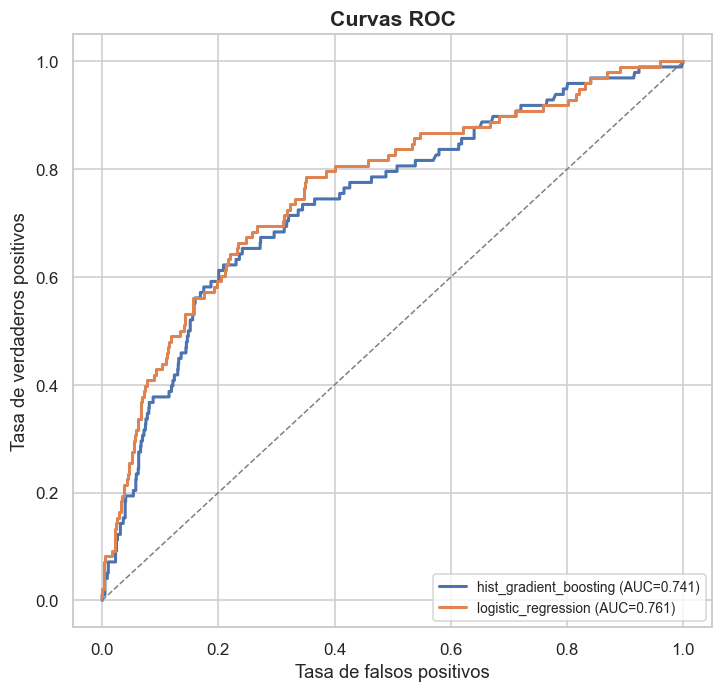

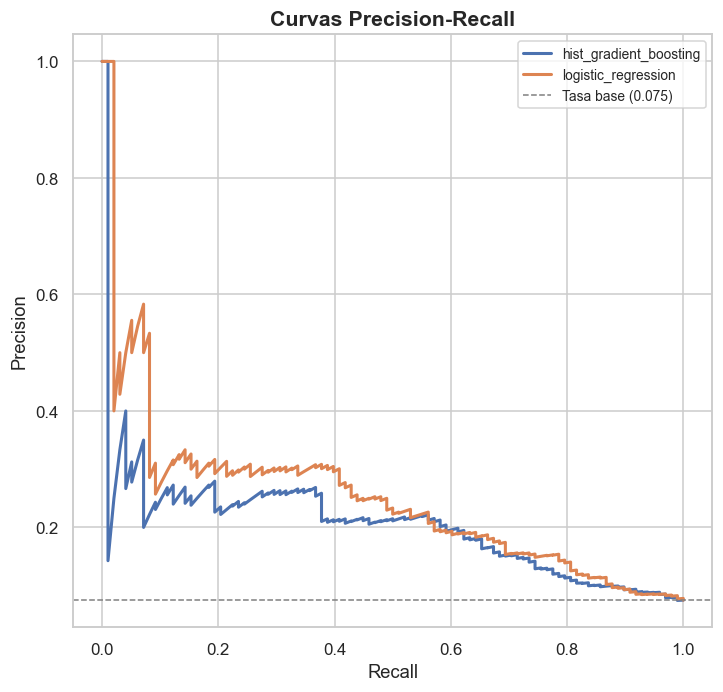

In [7]:
visualization.plot_roc_curves(res, save_as='roc_curves'); plt.show()
visualization.plot_pr_curves(res, base_rate=float(yte.mean()), save_as='pr_curves'); plt.show()

**Conclusión.** Los modelos de *boosting* dominan en Brier/LogLoss (mejor estimación de probabilidad), mientras que los modelos con `class_weight` balanceado logran más recall a costa de peor calibración — motivación directa del Notebook 05.